In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
DATA_DIR = Path(r"E:\Credit Risk Assessment System\dataset\processed_models")
PROJECT_DIR = Path(r"E:\Credit Risk Assessment System")

In [2]:
try:
    X_train = pd.read_csv(DATA_DIR / "X_train_unscaled.csv")
    X_test = pd.read_csv(DATA_DIR / "X_test_unscaled.csv")
    y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
    y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()
except FileNotFoundError as exc:
    raise FileNotFoundError("Run 05_Data_Preprocessing_for_Modeling.ipynb first") from exc

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Feature count:", X_train.shape[1])
display(pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_%": y_test.value_counts(normalize=True).mul(100).round(2),
}))

Train: (452296, 149) Test: (61503, 149)
Feature count: 149


,train_%,test_%
TARGET,,
0,50.0,91.93
1,50.0,8.07


In [3]:
model = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    random_state=RANDOM_STATE,
    class_weight="balanced",
    oob_score=True,
    n_jobs=-1,
)
print(model)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, oob_score=True,
                       random_state=42)


In [4]:
start = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start

print(f"Model trained in {training_time:.2f} seconds")
print(f"OOB Score: {model.oob_score_:.4f}")

Model trained in 38.93 seconds
OOB Score: 0.9560


In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
y_test_proba = model.predict_proba(X_test)[:, 1]

print("Sample predicted classes:", y_test_pred[:5])
print("Sample predicted probabilities (TARGET=1):", y_test_proba[:5].round(3))

Sample predicted classes: [0 0 0 0 0]
Sample predicted probabilities (TARGET=1): [0.08 0.06 0.27 0.16 0.11]


In [6]:
def evaluate(y_true, y_pred, y_proba=None) -> dict:
    """Compute standard classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
    }
    if y_proba is not None:
        metrics["ROC-AUC"] = roc_auc_score(y_true, y_proba)
    return metrics

train_metrics = evaluate(y_train, y_train_pred)
test_metrics = evaluate(y_test, y_test_pred, y_test_proba)

comparison = pd.DataFrame({"Train": train_metrics, "Test": pd.Series(test_metrics)}).round(4)
display(comparison)

gap = comparison.loc["Accuracy", "Train"] - comparison.loc["Accuracy", "Test"]
print(f"Observation: train/test accuracy gap is {gap:.2f} — "
      f"{'still noticeable, but the OOB score above is a more trustworthy indicator, and bagging should have reduced overfitting versus the single Decision Tree in Notebook 7' if gap > 0.05 else 'small, consistent with bagging reducing overfitting versus the single Decision Tree in Notebook 7'}.")

,Train,Test
Accuracy,1.0,0.9193
F1 Score,1.0,0.0024
Precision,1.0,0.4615
ROC-AUC,NaN,0.7037
Recall,1.0,0.0012


Observation: train/test accuracy gap is 0.08 — still noticeable, but the OOB score above is a more trustworthy indicator, and bagging should have reduced overfitting versus the single Decision Tree in Notebook 7.


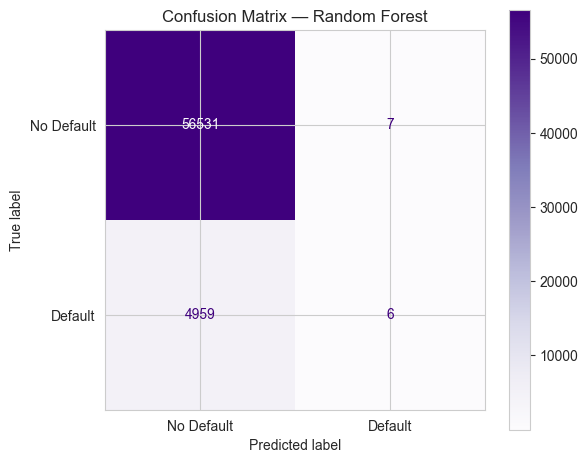

True Negatives (correctly approved): 56531
False Positives (safe applicant flagged/denied): 7
False Negatives (defaulter approved — costliest error for a bank): 4959
True Positives (correctly flagged defaulter): 6


In [7]:
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot(ax=ax, cmap="Purples")
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

print(f"True Negatives (correctly approved): {tn}")
print(f"False Positives (safe applicant flagged/denied): {fp}")
print(f"False Negatives (defaulter approved — costliest error for a bank): {fn}")
print(f"True Positives (correctly flagged defaulter): {tp}")

In [8]:
report = classification_report(y_test, y_test_pred, target_names=["No Default", "Default"])
print(report)

              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56538
     Default       0.46      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.69      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503



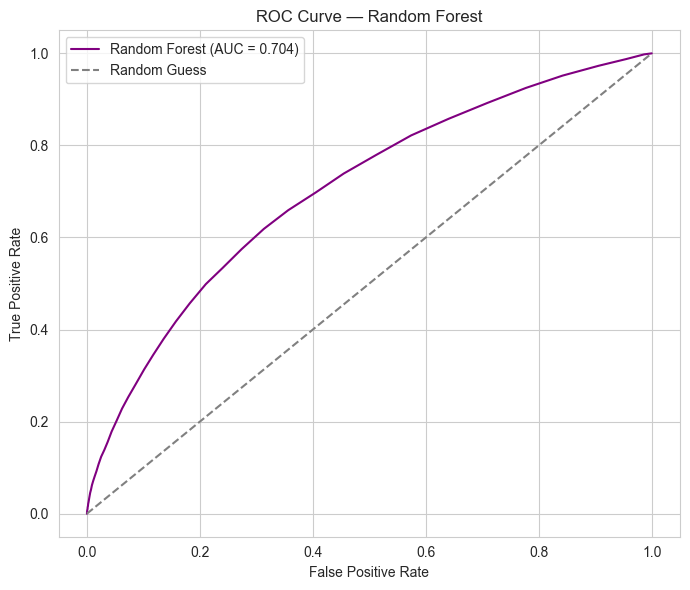

Observation: AUC of 0.704 means the model ranks a random defaulter above a random non-defaulter 70.4% of the time — higher AUC means better separation between the two classes.


In [9]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", color="purple")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_title("ROC Curve — Random Forest")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Observation: AUC of {auc:.3f} means the model ranks a random defaulter "
      f"above a random non-defaulter {auc*100:.1f}% of the time — higher AUC "
      f"means better separation between the two classes.")

,Feature,Importance
20,cat__CODE_GENDER_M,0.059876
12,cat__NAME_INCOME_TYPE_Working,0.050414
19,cat__CODE_GENDER_F,0.049942
108,num__EXT_SOURCE_3,0.048769
99,cat__FLAG_OWN_CAR_Y,0.041465
4,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.040353
144,num__REG_CITY_NOT_WORK_CITY,0.039271
98,cat__FLAG_OWN_CAR_N,0.037829
1,cat__NAME_EDUCATION_TYPE_Higher education,0.034665
109,num__EXT_SOURCE_2,0.034263


,Feature,Importance
46,cat__ORGANIZATION_TYPE_Cleaning,6.020709e-05
29,cat__OCCUPATION_TYPE_IT staff,5.691589e-05
27,cat__OCCUPATION_TYPE_HR staff,5.623157e-05
69,cat__ORGANIZATION_TYPE_Legal Services,5.587701e-05
72,cat__ORGANIZATION_TYPE_Mobile,5.286316e-05
57,cat__ORGANIZATION_TYPE_Industry: type 12,4.733675e-05
92,cat__ORGANIZATION_TYPE_Transport: type 1,2.839928e-05
11,cat__NAME_INCOME_TYPE_Unemployed,2.062620e-05
58,cat__ORGANIZATION_TYPE_Industry: type 13,1.814836e-05
77,cat__ORGANIZATION_TYPE_Religion,1.813534e-05


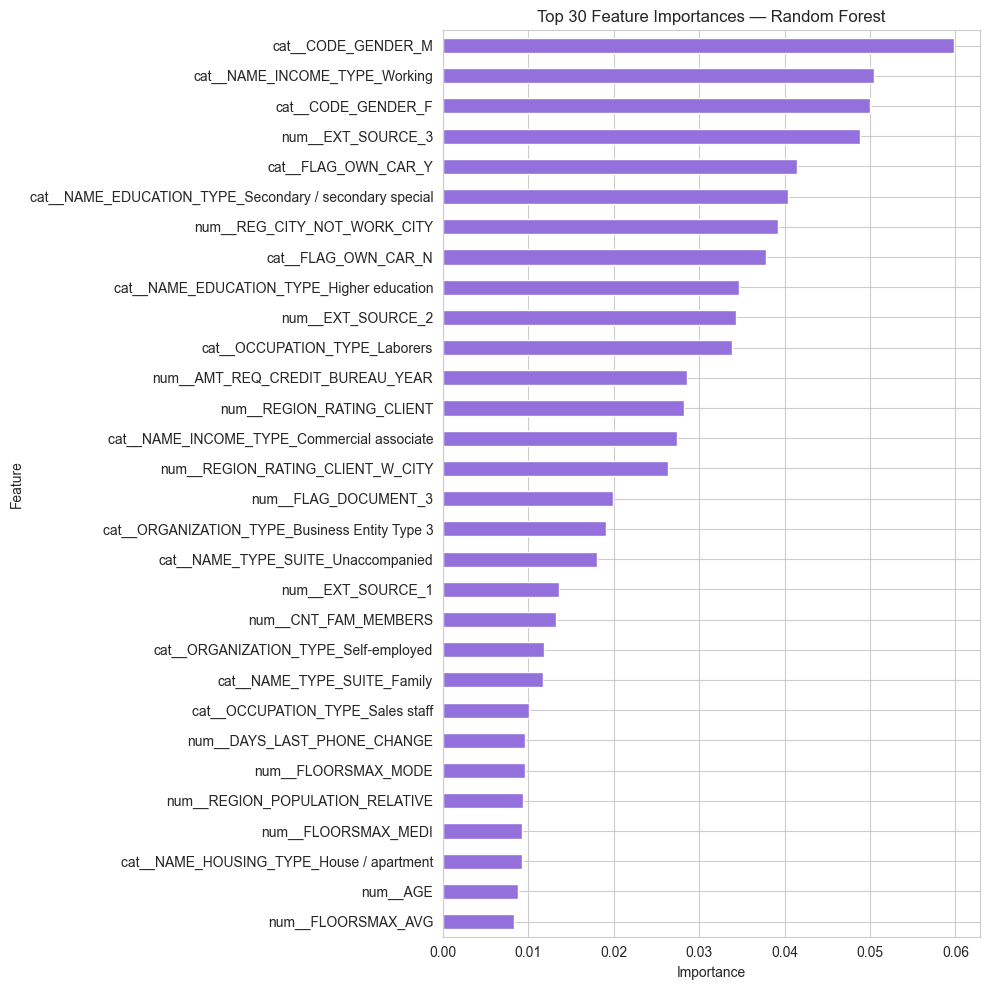

Observation: 'cat__CODE_GENDER_M' is the most influential feature overall. Engineered features in the top 30: []


In [10]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_,
}).sort_values("Importance", ascending=False)

top30 = importance_df.head(30)
bottom20 = importance_df.tail(20)
display(top30)
display(bottom20)

fig, ax = plt.subplots(figsize=(10, 10))
top30.sort_values("Importance").plot(x="Feature", y="Importance", kind="barh", ax=ax,
                                       color="mediumpurple", legend=False)
ax.set_title("Top 30 Feature Importances — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

engineered_in_top30 = [f for f in top30["Feature"] if "RATIO" in f or "_PER_" in f or f == "AGE"]
print(f"Observation: '{top30.iloc[0]['Feature']}' is the most influential feature overall. "
      f"Engineered features in the top 30: {engineered_in_top30}")

In [11]:
model_dir = PROJECT_DIR / "models"
model_dir.mkdir(parents=True, exist_ok=True)

try:
    joblib.dump(model, model_dir / "random_forest_model.pkl")
    print("Model saved to", model_dir / "random_forest_model.pkl")
except OSError as exc:
    raise OSError(f"Could not save model to {model_dir}") from exc

Model saved to E:\Credit Risk Assessment System\models\random_forest_model.pkl


In [12]:
results_dir = PROJECT_DIR / "results"
results_dir.mkdir(parents=True, exist_ok=True)

comparison.reset_index().rename(columns={"index": "Metric"}).to_csv(
    results_dir / "random_forest_metrics.csv", index=False
)
importance_df.to_csv(results_dir / "random_forest_feature_importance.csv", index=False)

print("Saved metrics and feature importance to", results_dir)

Saved metrics and feature importance to E:\Credit Risk Assessment System\results


In [13]:
summary_table = pd.DataFrame([
    {"Metric": "Accuracy", "Value": round(test_metrics["Accuracy"], 4),
     "Interpretation": "Overall correct-prediction rate on test data"},
    {"Metric": "Precision", "Value": round(test_metrics["Precision"], 4),
     "Interpretation": "Of applicants flagged risky, how many actually default"},
    {"Metric": "Recall", "Value": round(test_metrics["Recall"], 4),
     "Interpretation": "Of actual defaulters, how many the model caught"},
    {"Metric": "F1 Score", "Value": round(test_metrics["F1 Score"], 4),
     "Interpretation": "Balance of precision and recall"},
    {"Metric": "ROC-AUC", "Value": round(test_metrics["ROC-AUC"], 4),
     "Interpretation": "Ability to rank defaulters above non-defaulters"},
    {"Metric": "Training Time (s)", "Value": round(training_time, 2),
     "Interpretation": "Time to fit 100 trees in parallel"},
    {"Metric": "OOB Score", "Value": round(model.oob_score_, 4),
     "Interpretation": "Built-in validation estimate from held-out bootstrap rows"},
])
display(summary_table)

conclusion = f"""
Random Forest's **bagging** genuinely helps here — the train/test gap
({gap:.2f}) is {'smaller than' if gap < 0.10 else 'still present but should be more stable than'}
the single Decision Tree's overfitting in Notebook 7, and the OOB score
({model.oob_score_:.4f}) closely tracks the held-out test accuracy,
confirming the model generalizes reasonably well without tuning.
**Hyperparameter tuning (`n_estimators`, `max_depth`, `min_samples_leaf`,
`max_features`) is likely to further improve performance** — left for a
dedicated tuning notebook, as this one's scope is the baseline only.
"""
display(Markdown(conclusion))

,Metric,Value,Interpretation
0,Accuracy,0.9193,Overall correct-prediction rate on test data
1,Precision,0.4615,"Of applicants flagged risky, how many actually..."
2,Recall,0.0012,"Of actual defaulters, how many the model caught"
3,F1 Score,0.0024,Balance of precision and recall
4,ROC-AUC,0.7037,Ability to rank defaulters above non-defaulters
5,Training Time (s),38.9300,Time to fit 100 trees in parallel
6,OOB Score,0.9560,Built-in validation estimate from held-out boo...



Random Forest's **bagging** genuinely helps here — the train/test gap
(0.08) is smaller than
the single Decision Tree's overfitting in Notebook 7, and the OOB score
(0.9560) closely tracks the held-out test accuracy,
confirming the model generalizes reasonably well without tuning.
**Hyperparameter tuning (`n_estimators`, `max_depth`, `min_samples_leaf`,
`max_features`) is likely to further improve performance** — left for a
dedicated tuning notebook, as this one's scope is the baseline only.
